In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("../outputs/london_features_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.head())
print(df.shape)

   count_point_id direction_of_travel  count_date  hour region_name  \
0           26434                   W  2000-03-17    10      London   
1            8487                   N  2000-03-17    10      London   
2            8487                   S  2000-03-17    10      London   
3           38647                   N  2000-03-17    10      London   
4           38647                   S  2000-03-17    10      London   

  local_authority_name road_name road_category road_type   latitude  ...  \
0               Ealing       A40            TA     Major  51.535506  ...   
1             Lewisham     A2209            PA     Major  51.475304  ...   
2             Lewisham     A2209            PA     Major  51.475304  ...   
3             Havering     A1251            PA     Major  51.579516  ...   
4             Havering     A1251            PA     Major  51.579516  ...   

            timestamp  hour_of_day  day_of_week  month  year  day   lag_1  \
0 2000-03-17 10:00:00           10     

In [72]:
feature_cols = [
    "hour_of_day",
    "day_of_week",
    "month",
    "year",
    "day",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3"
]

target_col = "all_motor_vehicles"

In [73]:
import pandas as pd

df = pd.read_csv("../outputs/london_features_dataset.csv")
print(df.columns.tolist())
print(df[["all_motor_vehicles", "lag_1", "lag_2", "lag_3", "rolling_mean_3"]].head(10))

['count_point_id', 'direction_of_travel', 'count_date', 'hour', 'region_name', 'local_authority_name', 'road_name', 'road_category', 'road_type', 'latitude', 'longitude', 'link_length_km', 'pedal_cycles', 'cars_and_taxis', 'buses_and_coaches', 'LGVs', 'all_HGVs', 'all_motor_vehicles', 'timestamp', 'hour_of_day', 'day_of_week', 'month', 'year', 'day', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']
   all_motor_vehicles   lag_1   lag_2   lag_3  rolling_mean_3
0               853.0   945.0  2270.0  1469.0     1561.333333
1              1633.0   853.0   945.0  2270.0     1356.000000
2              1305.0  1633.0   853.0   945.0     1143.666667
3               994.0  1305.0  1633.0   853.0     1263.666667
4              1179.0   994.0  1305.0  1633.0     1310.666667
5              1174.0  1179.0   994.0  1305.0     1159.333333
6              1157.0  1174.0  1179.0   994.0     1115.666667
7              1303.0  1157.0  1174.0  1179.0     1170.000000
8              1559.0  1303.0  1157.0  1174.

In [74]:
df = df.sort_values(["count_point_id", "timestamp"]).reset_index(drop=True)

def split_group(group):
    split_index = int(len(group) * 0.8)
    group = group.copy()
    group["set"] = "train"
    group.iloc[split_index:, group.columns.get_loc("set")] = "test"
    return group

df = df.groupby("count_point_id", group_keys=False).apply(split_group)

train_df = df[df["set"] == "train"]
test_df = df[df["set"] == "test"]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (176456, 9)
Test shape: (44925, 9)


/var/folders/dv/56245rkx5zzcn8v4sx0xq87m0000gn/T/ipykernel_65657/1201177625.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("count_point_id", group_keys=False).apply(split_group)


In [75]:
print(df["set"].value_counts())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nTrain time range:")
print(train_df["timestamp"].min(), "to", train_df["timestamp"].max())

print("\nTest time range:")
print(test_df["timestamp"].min(), "to", test_df["timestamp"].max())

print("\nAny exact overlap of rows by point+timestamp?")
train_keys = set(zip(train_df["count_point_id"], train_df["timestamp"]))
test_keys = set(zip(test_df["count_point_id"], test_df["timestamp"]))
print(len(train_keys.intersection(test_keys)))

set
train    176456
test      44925
Name: count, dtype: int64
Train rows: 176456
Test rows: 44925

Train time range:
2000-03-17 10:00:00 to 2024-11-04 16:00:00

Test time range:
2000-05-12 17:00:00 to 2024-11-06 18:00:00

Any exact overlap of rows by point+timestamp?
574


In [76]:
print("\nSample test rows:")
print(test_df[["count_point_id", "timestamp", "all_motor_vehicles", "lag_1", "lag_2", "lag_3", "rolling_mean_3"]].head(10))


Sample test rows:
     count_point_id            timestamp  all_motor_vehicles   lag_1   lag_2  \
148            6000  2011-05-26 12:00:00              1120.0  1249.0  1175.0   
149            6000  2011-05-26 12:00:00              1345.0  1120.0  1249.0   
150            6000  2011-05-26 13:00:00               912.0  1345.0  1120.0   
151            6000  2011-05-26 13:00:00              1387.0   912.0  1345.0   
152            6000  2011-05-26 14:00:00               917.0  1387.0   912.0   
153            6000  2011-05-26 14:00:00              1646.0   917.0  1387.0   
154            6000  2011-05-26 15:00:00              2066.0  1646.0   917.0   
155            6000  2011-05-26 15:00:00              1198.0  2066.0  1646.0   
156            6000  2011-05-26 16:00:00              2400.0  1198.0  2066.0   
157            6000  2011-05-26 16:00:00              1124.0  2400.0  1198.0   

      lag_3  rolling_mean_3  
148  1249.0     1224.333333  
149  1175.0     1181.333333  
150  1249.

In [77]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

In [78]:
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 166.50717124127112
Baseline RMSE: 271.251295868288


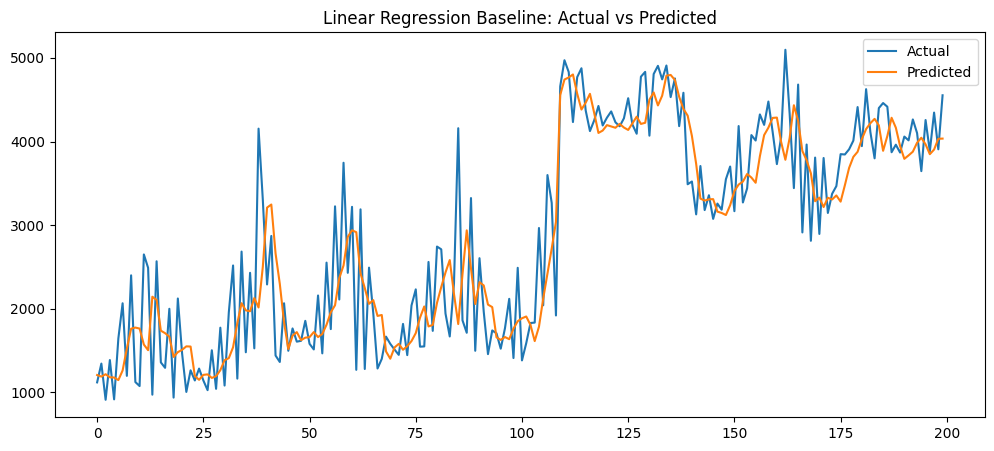

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(baseline_preds[:200], label="Predicted")
plt.legend()
plt.title("Linear Regression Baseline: Actual vs Predicted")
plt.show()

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(baseline_preds[:200], label="Predicted")
plt.legend()
plt.title("Linear Regression Baseline: Actual vs Predicted")
plt.savefig("../outputs/baseline_actual_vs_predicted.png", bbox_inches="tight")
plt.close()

In [83]:
from sklearn.metrics import r2_score

print("Baseline R2:", r2_score(y_test, baseline_preds))

Baseline R2: 0.9286659272175428
